In [1]:
!pip install quimb cotengra matplotlib

In [2]:
!pip install qiskit
!pip install qiskit-aer
!pip install matplotlib
!pip install pylatexenc

In [3]:
from qiskit import QuantumCircuit
import numpy as np

qc = QuantumCircuit.from_qasm_file("P7_rolling_ridge.qasm")

n = qc.num_qubits
angles = [0.0] * n

for instr in qc.data:
    op = instr.operation
    qubits = [q._index for q in instr.qubits]

    if op.name == "ry":
        angles[qubits[0]] += float(op.params[0])

    elif op.name == "rx":
        angles[qubits[0]] += float(op.params[0])

    elif op.name == "rz":
        angles[qubits[0]] += float(op.params[0])

    elif op.name == "u" or op.name == "u3":
        theta = float(op.params[0])
        angles[qubits[0]] += theta

In [4]:
bits = []

for theta in angles:

    p0 = np.cos(theta/2)**2
    p1 = np.sin(theta/2)**2

    if p1 > p0:
        bits.append("1")
    else:
        bits.append("0")

peak = "".join(bits[::-1])

print("Predicted peak:", peak)

Predicted peak: 1101000110011010101110000001010111001000001001


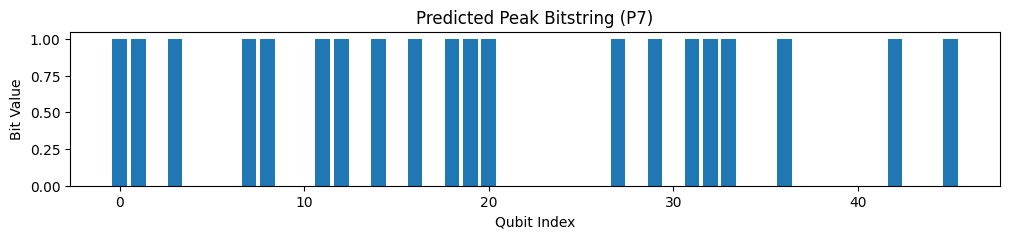

In [5]:
import matplotlib.pyplot as plt

values = [int(b) for b in peak]

plt.figure(figsize=(12,2))
plt.bar(range(len(values)), values)
plt.title("Predicted Peak Bitstring (P7)")
plt.xlabel("Qubit Index")
plt.ylabel("Bit Value")
plt.show()